# Sony (SONY) Stock — Technical Analysis, Volatility & Backtesting

**Business question:** What does 12+ years of Sony's daily price history say about its trend, momentum, and risk — and do standard technical-indicator strategies or time-series models actually add value over simply buying and holding?

Dataset: [Sony Stock Data (Kaggle)](https://www.kaggle.com/datasets/nilesh2042/sony-stock-data) — daily OHLCV for Sony (NYSE: SONY), 2014-01-02 to 2026-08-24 (3,179 trading days).

The CSV is included directly in `data/`, so this notebook runs as-is — no download needed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('data/sony_stock_data.csv', parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
print('Missing values:', df.isna().sum().sum())
print('Duplicate dates:', df.duplicated(subset='Date').sum())
df.shape

Missing values: 0
Duplicate dates: 0


(3179, 6)

## 1. Price & volume overview

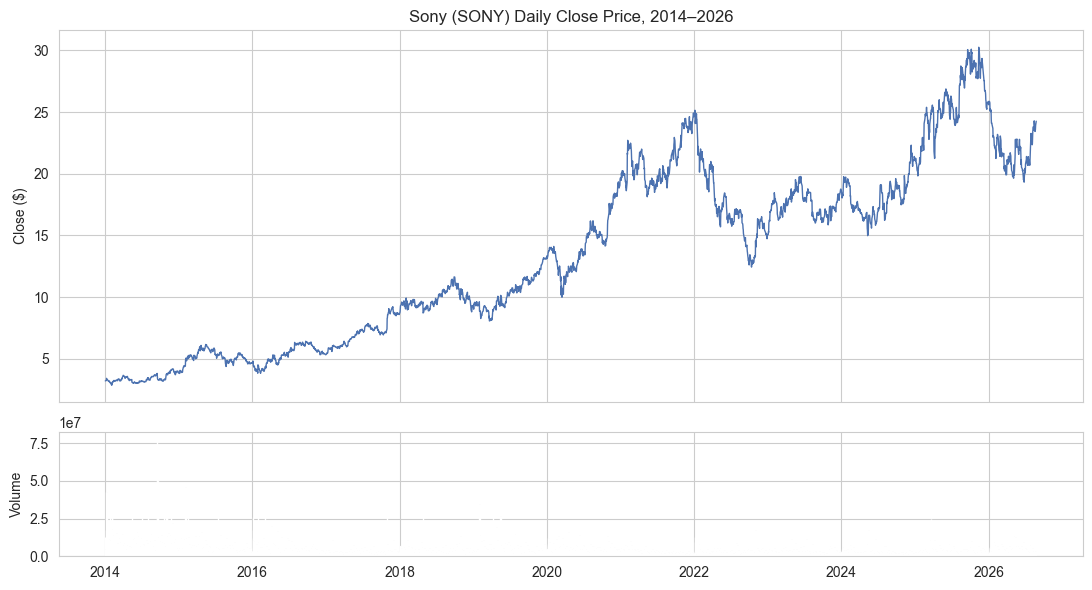

2014-01-02 -> 2026-08-24: $3.20 -> $24.26
Total return: 657.2% | CAGR: 17.4% over 12.6 years


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(df['Date'], df['Close'], color='#4C72B0', linewidth=1)
axes[0].set_title('Sony (SONY) Daily Close Price, 2014–2026')
axes[0].set_ylabel('Close ($)')

axes[1].bar(df['Date'], df['Volume'], color='#8C8C8C', width=1)
axes[1].set_ylabel('Volume')

plt.tight_layout()
plt.savefig('images/01_price_volume_overview.png', bbox_inches='tight', dpi=150)
plt.show()

start, end = df['Close'].iloc[0], df['Close'].iloc[-1]
years = (df['Date'].iloc[-1] - df['Date'].iloc[0]).days / 365.25
total_return = end / start - 1
cagr = (1 + total_return) ** (1 / years) - 1
print(f'{df["Date"].iloc[0].date()} -> {df["Date"].iloc[-1].date()}: ${start:.2f} -> ${end:.2f}')
print(f'Total return: {total_return:.1%} | CAGR: {cagr:.1%} over {years:.1f} years')

## 2. Technical indicators — moving averages (SMA/EMA)

Simple and exponential moving averages smooth out day-to-day noise to show the underlying trend. The classic reading: price above a rising 200-day SMA signals a long-term uptrend; a "golden cross" (50-day SMA crossing above the 200-day) is a common bullish signal, a "death cross" the bearish mirror.

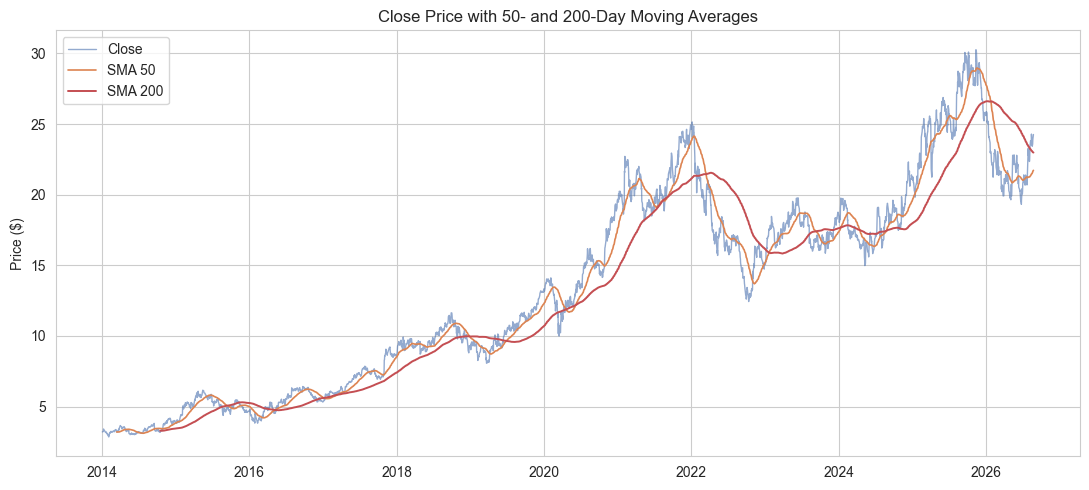

Latest close $24.26 vs SMA50 $21.72 vs SMA200 $22.98


In [3]:
df['SMA20'] = df['Close'].rolling(20).mean()
df['SMA50'] = df['Close'].rolling(50).mean()
df['SMA200'] = df['Close'].rolling(200).mean()
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

plt.figure(figsize=(11, 5))
plt.plot(df['Date'], df['Close'], label='Close', color='#4C72B0', linewidth=1, alpha=0.6)
plt.plot(df['Date'], df['SMA50'], label='SMA 50', color='#DD8452', linewidth=1.2)
plt.plot(df['Date'], df['SMA200'], label='SMA 200', color='#C44E52', linewidth=1.4)
plt.title('Close Price with 50- and 200-Day Moving Averages')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.savefig('images/02_moving_averages.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Latest close ${df['Close'].iloc[-1]:.2f} vs SMA50 ${df['SMA50'].iloc[-1]:.2f} vs SMA200 ${df['SMA200'].iloc[-1]:.2f}")

## 3. Momentum indicators — RSI & MACD

- **RSI(14)** ranges 0–100; readings above 70 are conventionally "overbought," below 30 "oversold."
- **MACD** (12-EMA minus 26-EMA) crossing above its 9-day signal line is a common bullish momentum signal.

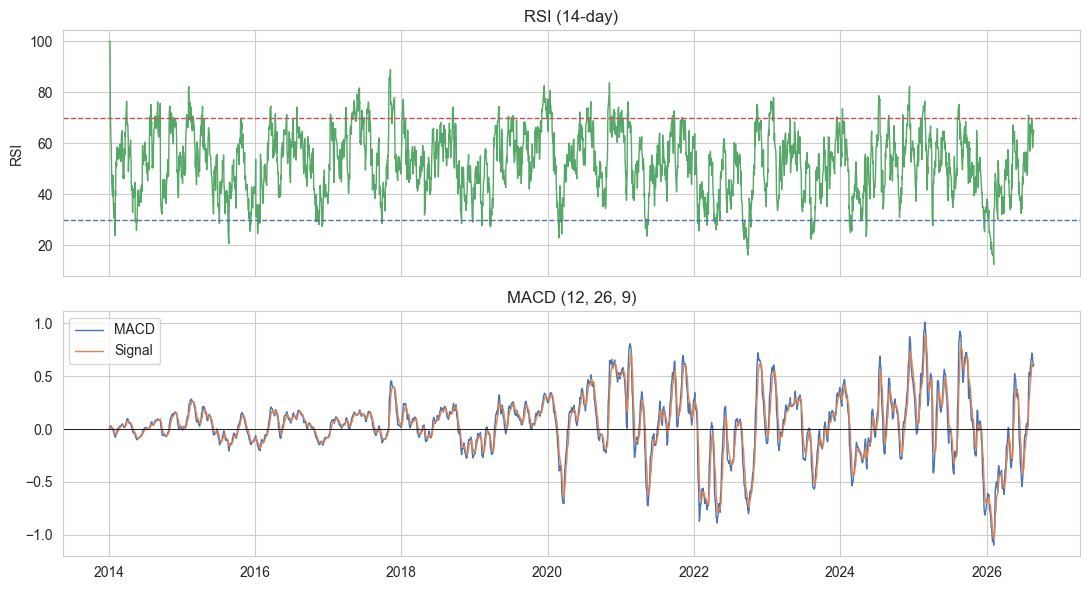

Latest RSI(14): 65.4
Latest MACD: 0.611 vs signal 0.616


In [4]:
delta = df['Close'].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()
rs = avg_gain / avg_loss
df['RSI14'] = 100 - (100 / (1 + rs))

ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(df['Date'], df['RSI14'], color='#55A868', linewidth=1)
axes[0].axhline(70, color='#C44E52', linestyle='--', linewidth=1)
axes[0].axhline(30, color='#4C72B0', linestyle='--', linewidth=1)
axes[0].set_title('RSI (14-day)')
axes[0].set_ylabel('RSI')

axes[1].plot(df['Date'], df['MACD'], label='MACD', color='#4C72B0', linewidth=1)
axes[1].plot(df['Date'], df['MACD_signal'], label='Signal', color='#DD8452', linewidth=1)
axes[1].axhline(0, color='black', linewidth=0.6)
axes[1].set_title('MACD (12, 26, 9)')
axes[1].legend()

plt.tight_layout()
plt.savefig('images/03_rsi_macd.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"Latest RSI(14): {df['RSI14'].iloc[-1]:.1f}")
print(f"Latest MACD: {df['MACD'].iloc[-1]:.3f} vs signal {df['MACD_signal'].iloc[-1]:.3f}")

## 4. Bollinger Bands

20-day moving average ± 2 standard deviations. Price touching the upper/lower band flags statistically stretched moves relative to recent volatility; band width itself tracks volatility (bands widen in volatile regimes, squeeze in calm ones).

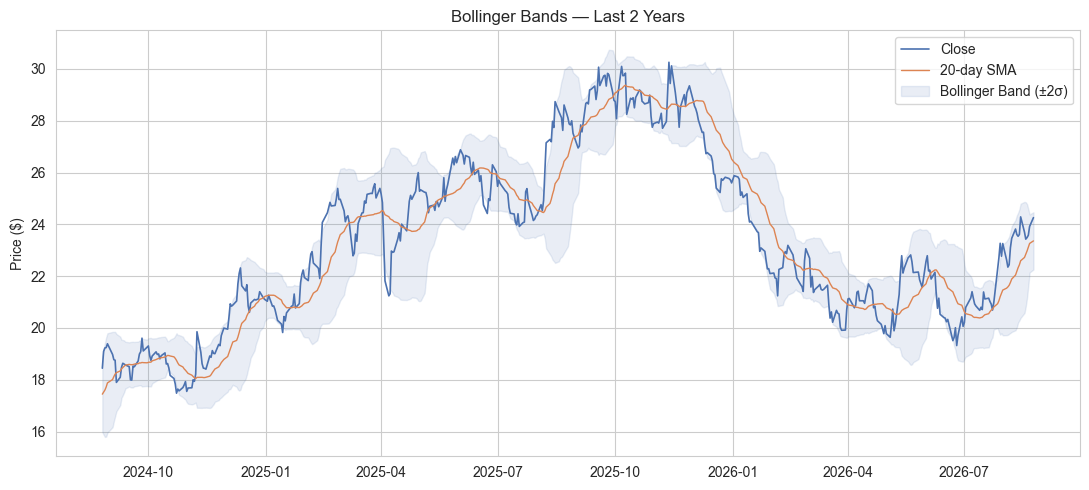

In [5]:
df['BB_mid'] = df['Close'].rolling(20).mean()
df['BB_std'] = df['Close'].rolling(20).std()
df['BB_upper'] = df['BB_mid'] + 2 * df['BB_std']
df['BB_lower'] = df['BB_mid'] - 2 * df['BB_std']

recent = df[df['Date'] >= df['Date'].max() - pd.Timedelta(days=730)]

plt.figure(figsize=(11, 5))
plt.plot(recent['Date'], recent['Close'], label='Close', color='#4C72B0', linewidth=1.2)
plt.plot(recent['Date'], recent['BB_mid'], label='20-day SMA', color='#DD8452', linewidth=1)
plt.fill_between(recent['Date'], recent['BB_lower'], recent['BB_upper'], color='#4C72B0', alpha=0.12, label='Bollinger Band (±2σ)')
plt.title('Bollinger Bands — Last 2 Years')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.savefig('images/04_bollinger_bands.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Volatility analysis

Daily returns and rolling annualized volatility, to see how risk has shifted across macro cycles (e.g. the 2020 COVID crash, the 2022 rate-hiking cycle).

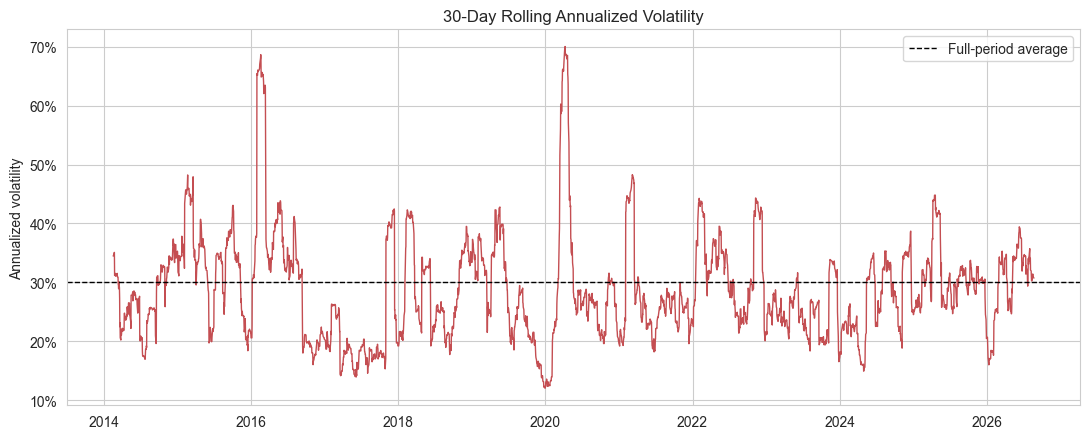

Annualized volatility by year:
year
2014    0.285
2015    0.335
2016    0.365
2017    0.227
2018    0.299
2019    0.274
2020    0.337
2021    0.282
2022    0.333
2023    0.251
2024    0.275
2025    0.307
2026    0.313
Name: ret, dtype: float64

Full-period annualized volatility: 30.0%


In [6]:
df['ret'] = df['Close'].pct_change()
df['rolling_vol_30d'] = df['ret'].rolling(30).std() * np.sqrt(252)

plt.figure(figsize=(11, 4.5))
plt.plot(df['Date'], df['rolling_vol_30d'], color='#C44E52', linewidth=1)
plt.axhline(df['ret'].std() * np.sqrt(252), color='black', linestyle='--', linewidth=1, label='Full-period average')
plt.title('30-Day Rolling Annualized Volatility')
plt.ylabel('Annualized volatility')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.legend()
plt.tight_layout()
plt.savefig('images/05_volatility_over_time.png', bbox_inches='tight', dpi=150)
plt.show()

df['year'] = df['Date'].dt.year
vol_by_year = (df.groupby('year')['ret'].std() * np.sqrt(252)).round(3)
print('Annualized volatility by year:')
print(vol_by_year)
print(f"\nFull-period annualized volatility: {df['ret'].std() * np.sqrt(252):.1%}")

## 6. Time series forecasting (ARIMA)

We hold out the final 60 trading days as a test set and fit an ARIMA(5,1,0) model on everything before it, then compare two forecasting approaches against two naive baselines: a genuinely fair test of whether a classic time-series model beats "assume nothing changes."

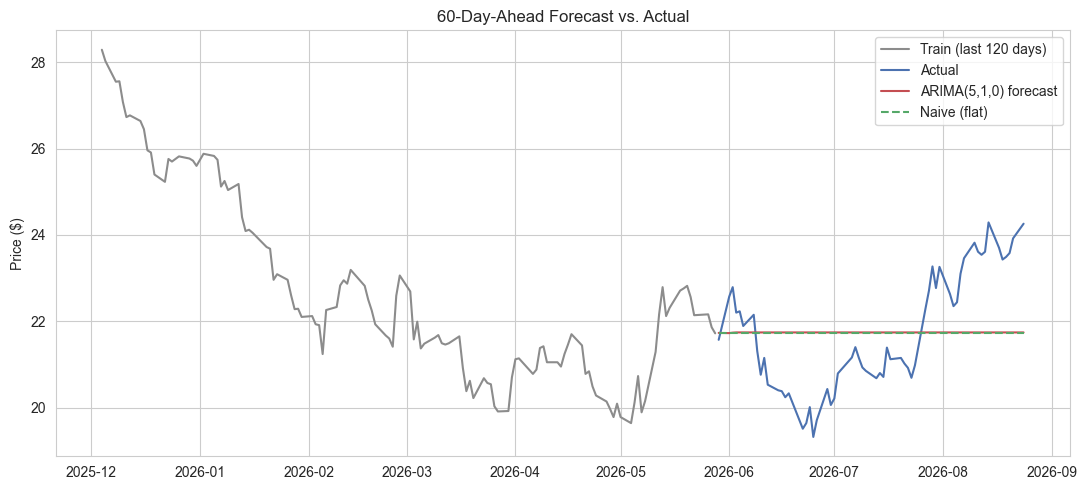

60-day-ahead RMSE  |  ARIMA: 1.362  |  Naive flat: 1.362  |  Naive random-walk: 0.443


In [7]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

close = df.set_index('Date')['Close']
test_size = 60
train, test = close.iloc[:-test_size], close.iloc[-test_size:]

fit = ARIMA(train, order=(5, 1, 0)).fit()
forecast_multistep = fit.forecast(steps=test_size)

naive_flat = pd.Series(train.iloc[-1], index=test.index)
naive_walk = test.shift(1)
naive_walk.iloc[0] = train.iloc[-1]

plt.figure(figsize=(11, 5))
plt.plot(train.index[-120:], train.values[-120:], label='Train (last 120 days)', color='#8C8C8C')
plt.plot(test.index, test.values, label='Actual', color='#4C72B0', linewidth=1.5)
plt.plot(test.index, forecast_multistep.values, label='ARIMA(5,1,0) forecast', color='#C44E52', linewidth=1.5)
plt.plot(test.index, naive_flat.values, label='Naive (flat)', color='#55A868', linestyle='--')
plt.title(f'{test_size}-Day-Ahead Forecast vs. Actual')
plt.ylabel('Price ($)')
plt.legend()
plt.tight_layout()
plt.savefig('images/06_forecast_vs_actual.png', bbox_inches='tight', dpi=150)
plt.show()

rmse_arima = np.sqrt(((forecast_multistep.values - test.values) ** 2).mean())
rmse_flat = np.sqrt(((naive_flat.values - test.values) ** 2).mean())
rmse_walk = np.sqrt(((naive_walk.values - test.values) ** 2).mean())
print(f'{test_size}-day-ahead RMSE  |  ARIMA: {rmse_arima:.3f}  |  Naive flat: {rmse_flat:.3f}  |  Naive random-walk: {rmse_walk:.3f}')

**Multi-step result:** over a 60-day horizon, ARIMA's forecast is essentially indistinguishable from just assuming the price freezes at its last known value (RMSE 1.36 vs. 1.36) — and both are far worse than a same-day random-walk baseline. This is expected: ARIMA has no way to know future news/earnings, so its long-horizon forecast collapses toward the unconditional trend.

A fairer test is **one-step-ahead, walk-forward**: refit-free updates, forecasting only tomorrow using everything known up to today, which is how these models are actually used in practice.

In [8]:
current_fit = fit
preds = []
for date, actual in test.items():
    preds.append(current_fit.forecast(steps=1).iloc[0])
    current_fit = current_fit.append([actual], refit=False)
preds = pd.Series(preds, index=test.index)

rmse_1step = np.sqrt(((preds.values - test.values) ** 2).mean())
mape_1step = (np.abs(preds.values - test.values) / test.values).mean()
mape_walk = (np.abs(naive_walk.values - test.values) / test.values).mean()

pd.DataFrame({
    'RMSE': [rmse_1step, rmse_walk],
    'MAPE': [mape_1step, mape_walk],
}, index=['ARIMA(5,1,0) 1-step walk-forward', 'Naive random-walk (yesterday\'s price)']).round(4)

,RMSE,MAPE
"ARIMA(5,1,0) 1-step walk-forward",0.4432,0.0162
Naive random-walk (yesterday's price),0.4431,0.0163


**One-step result:** walk-forward ARIMA ties the naive random-walk baseline almost exactly (RMSE 0.443 vs. 0.443, MAPE 1.62% vs. 1.63%). This is the textbook finding for daily stock prices: they behave close enough to a random walk that a classic ARIMA model adds no measurable forecasting edge over "tomorrow's price ≈ today's price." Any perceived edge from a fitted time-series model here should be treated with real skepticism.

## 7. Backtesting — SMA(20/50) crossover vs. buy & hold

A simple, widely-used trend-following rule: be long when the 20-day SMA is above the 50-day SMA, flat otherwise. Signals are lagged one day (trade on the next day's return) to avoid look-ahead bias. No transaction costs or slippage are modeled — a real caveat given 59 trades over the period.

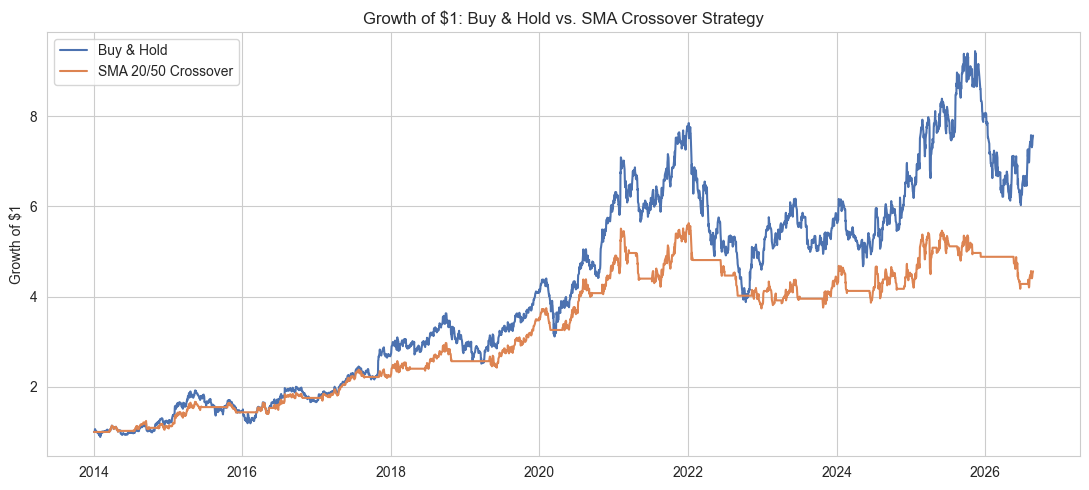

Trades: 59 | Time in market: 59.9%


,Total return,CAGR,Ann. volatility,Sharpe (rf=0),Max drawdown
Buy & Hold,6.572,0.174,0.300,0.684,-0.506
SMA 20/50 Crossover,3.563,0.128,0.215,0.667,-0.336


In [9]:
df['signal'] = np.where(df['SMA20'] > df['SMA50'], 1, 0)
df['signal'] = df['signal'].shift(1)
df['strat_ret'] = df['signal'] * df['ret']

bt = df.dropna(subset=['strat_ret']).copy()
bh_cum = (1 + bt['ret']).cumprod()
strat_cum = (1 + bt['strat_ret']).cumprod()

plt.figure(figsize=(11, 5))
plt.plot(bt['Date'], bh_cum, label='Buy & Hold', color='#4C72B0')
plt.plot(bt['Date'], strat_cum, label='SMA 20/50 Crossover', color='#DD8452')
plt.title('Growth of $1: Buy & Hold vs. SMA Crossover Strategy')
plt.ylabel('Growth of $1')
plt.legend()
plt.tight_layout()
plt.savefig('images/07_backtest_equity_curve.png', bbox_inches='tight', dpi=150)
plt.show()

def max_dd(cum):
    return (cum / cum.cummax() - 1).min()

years_bt = (bt['Date'].iloc[-1] - bt['Date'].iloc[0]).days / 365.25

def summarize(returns, cum, label):
    total = cum.iloc[-1] - 1
    cagr = (1 + total) ** (1 / years_bt) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = returns.mean() / returns.std() * np.sqrt(252)
    return {'Total return': total, 'CAGR': cagr, 'Ann. volatility': vol, 'Sharpe (rf=0)': sharpe, 'Max drawdown': max_dd(cum)}

summary = pd.DataFrame({
    'Buy & Hold': summarize(bt['ret'], bh_cum, 'bh'),
    'SMA 20/50 Crossover': summarize(bt['strat_ret'], strat_cum, 'strat'),
}).T
print(f"Trades: {(bt['signal'].diff().abs() > 0).sum()} | Time in market: {bt['signal'].mean():.1%}")
summary.round(3)

**Backtest result:** the SMA crossover strategy gives up meaningful upside (12.8% CAGR vs. 17.4% for buy & hold) but cuts risk substantially — annualized volatility 21.5% vs. 30.0%, max drawdown -33.6% vs. -50.6% — while sitting in cash 40% of the time. Risk-adjusted (Sharpe), the two are essentially tied (0.67 vs. 0.68). This is a realistic outcome for a simple trend-following rule: it doesn't create free alpha, it trades some return for materially lower drawdown — and that trade-off still ignores transaction costs across 59 trades.

## 8. Key findings & recommendations

**Findings:**
- Sony returned **657%** total (**17.4% CAGR**) from Jan 2014 to Aug 2026, but with **30% annualized volatility** and a **-50.6% max drawdown** (around Oct 2022) — a high-return, high-risk ride, not a smooth one.
- Yearly volatility ranged from **22.7% (2017)** to **36.5% (2016)**, with clear spikes in **2020** (COVID) and **2022** (rate-hiking cycle / yen weakness) — risk is regime-dependent, not constant, which matters for position sizing and options pricing.
- **ARIMA adds no measurable edge over a naive random-walk forecast** at either a 60-day horizon (ties a flat-price baseline) or a fair 1-step walk-forward horizon (RMSE 0.443 vs. 0.443 for "tomorrow = today"). Daily price *forecasting* is not where a classic time-series model earns its keep on this stock.
- A simple **SMA(20/50) crossover strategy trades return for risk**, not for free performance: -4.6pp CAGR but ~1500bps less volatility and ~17pp shallower drawdowns than buy & hold, landing at essentially the same Sharpe ratio (0.67 vs 0.68).
- **RSI(14) and MACD are momentum/timing tools, not forecasting tools** — useful for reading current trend strength (currently RSI ≈ 65, MACD above its signal line, price above both the 50- and 200-day SMA — a moderately bullish, non-overbought technical picture as of the last observation), but they don't predict direction any better than the ARIMA test above suggests price data alone can.

**Recommendations:**
1. Don't rely on ARIMA (or similar univariate time-series models) for daily price *direction* forecasts on this stock — the data here behaves too close to a random walk. If forecasting is the goal, look to models that incorporate external signals (earnings, macro, options-implied volatility), not price history alone.
2. Size positions and set stop-losses using the **regime-aware volatility view** (Section 5), not a single blanket volatility figure — 2020/2022-style spikes can more than double typical risk.
3. If using a trend-following rule like SMA crossover, frame it explicitly as a **risk-management tool** (smoother ride, shallower drawdowns) rather than a return-enhancer — and account for transaction costs before deploying it live.
4. Treat RSI/MACD/Bollinger readings as **context for entries/exits** around a thesis formed elsewhere, not as standalone predictive signals.

Full code and outputs are in this notebook.